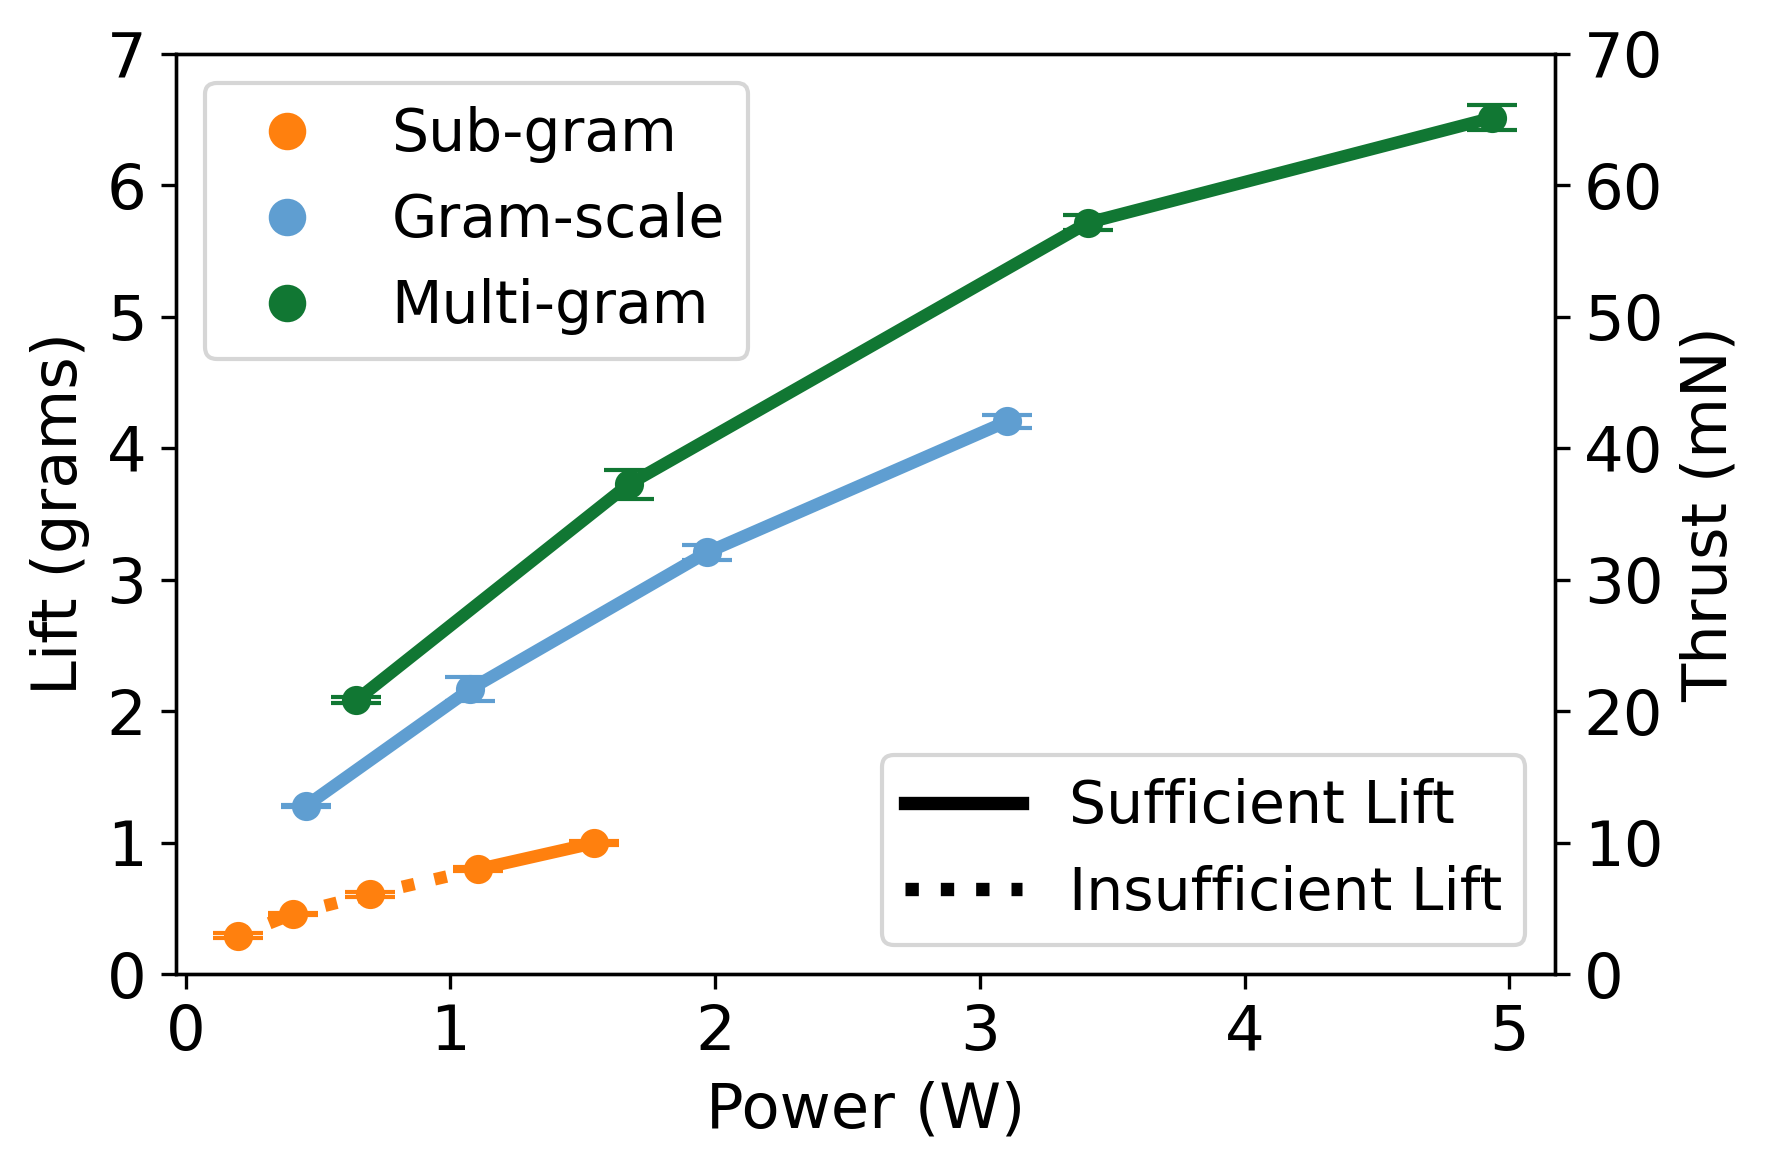

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# --- Font size variables ---
legend_fontsize = 14
label_fontsize  = 15
tick_fontsize   = 15

# --- Load and process data ---
url = (
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vRJobAHe6JC6Kfho9--uNA5N0ipBnLJsFXsVdc1wamykcfBLSS0pS0uowqVUTTJs1BK6YjPE17ymKYd/pub?output=csv"
)
df = pd.read_csv(url)

# Ensure numeric columns
for col in ['Motor Voltage (V)', 'Power (W)', 'Lift (grams)', 'Average Thrust (N)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Design Name','Power (W)','Lift (grams)'])

# Aggregate
grouped = (
    df
    .groupby(['Design Name','Motor Voltage (V)'], as_index=False)
    .agg(
        avg_power    = ('Power (W)',          'mean'),
        mean_lift    = ('Lift (grams)',       'mean'),
        std_lift     = ('Lift (grams)',       'std'),
        mean_thrust  = ('Average Thrust (N)', 'mean'),
    )
)

# Define a manual color scheme  |  ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF']
# Color & threshold by prototype
color_scheme = {
    "Sub-gram":   "#FF800E",
    "Gram-scale": "#5F9ED1",
    "Multi-gram": "#117733"
}
lift_thresholds = {
    "Sub-gram":   0.688,
    "Gram-scale": 1.00,
    "Multi-gram": 1.64
}

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Plot each design with dashed/solid segments
for design, color in color_scheme.items():
    data = grouped[grouped["Design Name"] == design].sort_values("avg_power")
    x    = data["avg_power"]
    y    = data["mean_lift"]
    yerr = data["std_lift"]
    thr  = lift_thresholds[design]

    x_vals = x.to_numpy()
    y_vals = y.to_numpy()
    yerr_vals = yerr.to_numpy()

    # Plot each line segment independently
    for i in range(len(x_vals) - 1):
        x_seg = x_vals[i:i+2]
        y_seg = y_vals[i:i+2]

        if np.all(y_seg >= thr):
            linestyle = '-'      # feasible
        else:
            linestyle = ':'      # infeasible or crossing threshold

        ax.plot(
            x_seg,
            y_seg,
            linestyle=linestyle,
            color=color,
            linewidth=3
        )

    # Plot markers and error bars once
    ax.errorbar(
        x_vals,
        y_vals,
        yerr=yerr_vals,
        fmt='o',
        capsize=6,
        markersize=6,
        color=color,
        zorder=5
    )

#plt.axhline(y=0.688, color=color_scheme["Sub-gram"], linestyle=':', zorder=1)

# Labels & ticks
ax.set_xlabel("Power (W)",      fontsize=label_fontsize)
ax.set_xticks([0,1,2,3,4,5])
ax.set_ylabel("Lift (grams)",   fontsize=label_fontsize)
ax.set_ylim(0, 7)
ax.tick_params(axis='both', labelsize=tick_fontsize)

# # Horizontal threshold lines
# for design, yval in lift_thresholds.items():
#     ax.axhline(y=yval,
#                color=color_scheme[design],
#                linestyle=':',
#                alpha=0.5,
#                zorder=1)

# Twin axis for thrust (mN)
ax2 = ax.twinx()
k = 10 #9.80665  # scale grams→mN
y0, y1 = ax.get_ylim()
ax2.set_ylim(y0 * k, y1 * k)
ax2.set_yticks(ax.get_yticks() * k)
ax2.set_ylabel("Thrust (mN)", fontsize=label_fontsize)
ax2.tick_params(axis='y', labelsize=tick_fontsize)
ax2.set_zorder(1)
ax2.patch.set_visible(False)

# Legend: design colors
color_handles = [
    mlines.Line2D([], [], color=color, marker='o', linestyle='None',
                  markersize=8, label=design)
    for design, color in color_scheme.items()
]
legend1 = ax.legend(handles=color_handles,
                    loc='upper left',
                    fontsize=legend_fontsize,
                    title_fontsize=legend_fontsize)

# Legend: feasibility style
feas = mlines.Line2D([], [], color='black', linestyle='-',  linewidth=3.2, label='Sufficient Lift')
infe = mlines.Line2D([], [], color='black', linestyle=':', linewidth=3.2, label='Insufficient Lift')
legend2 = ax.legend(handles=[feas, infe],
                    loc='lower right',
                    fontsize=legend_fontsize,
                    title_fontsize=legend_fontsize)

# Restore first legend
ax.add_artist(legend1)
plt.tight_layout()
plt.show()